# Credit Scorecard — Loan Repayment Prediction

## Project Overview

This notebook builds an **end-to-end credit scorecard** using the LendingClub loan dataset (2007–2014). 
A credit scorecard is a numerical tool that financial institutions use to measure the risk of non-repayment 
associated with a loan application. The final output is a **scaled score** (similar to a FICO score) 
where higher scores indicate lower default risk.

### Pipeline at a glance

```
Data Loading
  → EDA & Target Definition
  → Feature Cleaning
  → Train / Test Split          ← must happen before ANY WOE/IV computation
  → WOE + IV Calculation        ← on training data only
  → IV Filtering                ← remove weak (< 0.02) and suspicious (> 0.49) predictors
  → WOE Transformation          ← apply WOE values to both train and test
  → Feature Scaling             ← fit scaler on train only
  → Logistic Regression         ← statsmodels for p-value selection, sklearn for prediction
  → Model Evaluation            ← confusion matrix, ROC-AUC, Youden's J
  → Score Scaling               ← convert probabilities to a 300-850 style scorecard
  → Model Persistence           ← save artefacts for deployment
```

---
## Section 1 — Setup and Imports

We consolidate all imports at the top so that dependency issues surface immediately rather than 
mid-run. We also set a global random seed to make results reproducible across reruns.

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import json
import traceback
import re
import time
from pathlib import Path

import numpy as np
import pandas as pd
from scipy.stats import spearmanr

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from interpret.glassbox import ExplainableBoostingClassifier
from interpret import show

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    auc
)

import statsmodels.api as sm
import joblib

plt.rc('font', size=13)
sns.set(style='whitegrid', color_codes=True)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# ── Portable paths ───────────────────────────────────────────────────────────

BASE_DIR = Path.cwd().parent

DATA_FILE = BASE_DIR / 'data' / 'original' / 'loan_data_2007_2014.csv'

IV_CACHE = BASE_DIR / 'data' / 'processed' / 'final_iv.csv'

IV_SUMMARY = BASE_DIR / 'data' / 'processed' / 'test.csv'

ARTEFACTS = BASE_DIR / 'artefacts'

# Create directory if missing
ARTEFACTS.mkdir(parents=True, exist_ok=True)

print('Root directory:', BASE_DIR)
print('Artefacts will be saved to:', ARTEFACTS)

Root directory: c:\Users\sandi\Desktop\ML Working Folder\loan_repayment_credit_score_detection
Artefacts will be saved to: c:\Users\sandi\Desktop\ML Working Folder\loan_repayment_credit_score_detection\artefacts


---
## Section 2 — Data Loading

We load the raw LendingClub dataset. The dataset contains **~466 K rows × 74 columns** 
covering loan applications from 2007 to 2014.

In [64]:
# ── Load data ── 
df_loan = pd.read_csv(DATA_FILE, index_col=0, low_memory=False)

print(f'Dataset shape: {df_loan.shape}')
df_loan.head(3)

Dataset shape: (466285, 74)


,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m
0,1077501,1296599,5000,5000,4975.0,36 months,10.65,162.87,B,B2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1077430,1314167,2500,2500,2500.0,60 months,15.27,59.83,C,C4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1077175,1313524,2400,2400,2400.0,36 months,15.96,84.33,C,C5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [65]:
# ── Missing-value profile ────────────────────────────────────────────────────
missing_pct = df_loan.isnull().mean() * 100
print('Columns with > 10% missing values:')
print(missing_pct[missing_pct > 10].sort_values(ascending=False).to_string())

Columns with > 10% missing values:
dti_joint                      100.000000
annual_inc_joint               100.000000
verification_status_joint      100.000000
mths_since_rcnt_il             100.000000
total_bal_il                   100.000000
open_il_24m                    100.000000
open_il_12m                    100.000000
open_il_6m                     100.000000
open_acc_6m                    100.000000
inq_fi                         100.000000
open_rv_24m                    100.000000
max_bal_bc                     100.000000
all_util                       100.000000
inq_last_12m                   100.000000
total_cu_tl                    100.000000
il_util                        100.000000
open_rv_12m                    100.000000
mths_since_last_record          86.566585
mths_since_last_major_derog     78.773926
desc                            72.981975
mths_since_last_delinq          53.690554
next_pymnt_d                    48.728567
tot_coll_amt                    15.071469

---
## Section 3 — EDA and Target Variable Definition

### Defining 'Good' and 'Bad' loans

The raw `loan_status` column has many values (`Current`, `In Grace Period`, `Late (31-120 days)`, etc.). 
For a **binary credit scorecard** we need exactly two classes:

| Raw status | Encoded as | Meaning |
|------------|-----------|--------|
| `Fully Paid` | **0** — Good | Borrower repaid in full |
| `Charged Off` / `Default` | **1** — Bad | Lender wrote off the loan |

Loans with ambiguous statuses (`Current`, `In Grace Period`, `Late`) are **excluded** 
because we cannot yet determine their final outcome — including them would add label noise.

### Why do we also check class balance?
Logistic regression is sensitive to class imbalance. We will visualise the split here 
and compute class weights later to handle any imbalance during model fitting.

In [66]:
# ── Filter to unambiguous loan outcomes ─────────────────────────────────────
loan_filter = df_loan['loan_status'].isin(['Fully Paid', 'Charged Off', 'Default'])
df_loan = df_loan[loan_filter].copy()
print('Status distribution after filtering:')
print(df_loan['loan_status'].value_counts())

Status distribution after filtering:
loan_status
Fully Paid     184739
Charged Off     42475
Default           832
Name: count, dtype: int64


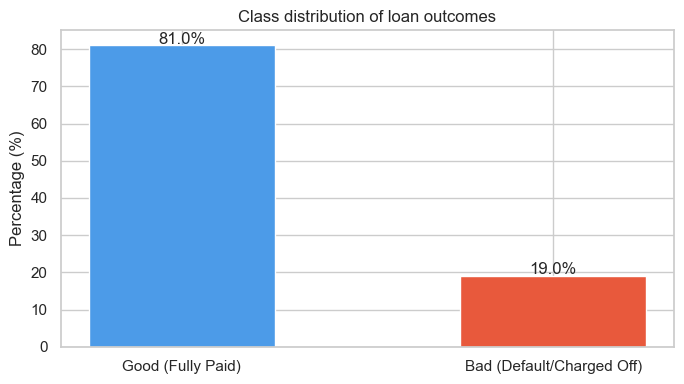

Good : Bad ratio ≈ 81.0% : 19.0%


In [67]:
# ── Encode target: 0 = Good (Fully Paid), 1 = Bad (Default/Charged Off) ─────
df_loan['Late_Loan'] = (df_loan['loan_status'] != 'Fully Paid').astype(int)

# ── Class balance visualisation ──────────────────────────────────────────────
counts = df_loan['Late_Loan'].value_counts(normalize=True) * 100

labels = {
    0: 'Good (Fully Paid)',
    1: 'Bad (Default/Charged Off)'
}

colors = ['#4C9BE8', '#E8593C']

fig, ax = plt.subplots(figsize=(7, 4))

ax.bar(
    [labels[i] for i in counts.index],
    counts.values,
    color=colors,
    width=0.5
)

for i, v in enumerate(counts.values):
    ax.text(i, v + 0.5, f'{v:.1f}%', ha='center', fontsize=12)

ax.set_ylabel('Percentage (%)')
ax.set_title('Class distribution of loan outcomes')

plt.tight_layout()
plt.show()

print(f'Good : Bad ratio ≈ {counts[0]:.1f}% : {counts[1]:.1f}%')

---
## Section 4 — Feature Engineering and Cleaning

### Step 4a — Drop columns with > 10% missing values
A column that is mostly empty cannot form reliable WOE bins. We apply a 10 % threshold 
as a conservative cut-off.

### Step 4b — Drop leaky and irrelevant columns
Several columns must be excluded for conceptual reasons:

- **Post-origination features** (`total_pymnt`, `recoveries`, `last_pymnt_amnt`, etc.) — these 
  are only known *after* the loan has been issued. Using them would mean the model sees the 
  future, which is data leakage in the strictest sense.
- **ID-like columns** (`id`, `member_id`, `url`, `zip_code`) — high cardinality with no 
  predictive signal.
- **Redundant encodings** (`sub_grade` is a finer version of `grade`; `funded_amnt` is 
  almost identical to `loan_amnt`).

### Step 4c — Missing value imputation
For the remaining columns:

- **Continuous variables** → impute with the **median** (robust to skew and outliers).
- **Count variables** (e.g. `collections_12_mths_ex_med`) → impute with **0** because 
  the vast majority of borrowers have zero collections. Using the mean would give a 
  non-integer value (e.g. 0.037) which then gets misclassified into a decimal-valued bin.
- **Categorical / text variables** → impute with `'Unknown'`.

### Step 4d — Outlier treatment (flooring & capping)
Extreme values in continuous variables can distort WOE bins by creating a very small 
bucket at one tail. We cap at the 99th percentile and floor at the 1st percentile.

In [68]:
# ── 4a: Drop columns with > 10% missing values ───────────────────────────────
high_missing = df_loan.isnull().mean() > 0.10
df_loan = df_loan.drop(columns=df_loan.columns[high_missing])
print(f'Remaining columns after missing-value drop: {df_loan.shape[1]}')

Remaining columns after missing-value drop: 50


In [69]:
# ── 4b: Drop leaky and irrelevant columns ────────────────────────────────────
DROP_COLS = [
    # Identifiers
    'id', 'member_id', 'url', 'zip_code', 'policy_code',
    # Target encoding (keep Late_Loan, not the raw string)
    'loan_status',
    # Post-origination / leaky payment outcomes
    'out_prncp', 'out_prncp_inv', 'total_pymnt', 'total_pymnt_inv',
    'total_rec_prncp', 'total_rec_int', 'total_rec_late_fee',
    'recoveries', 'collection_recovery_fee', 'last_pymnt_amnt',
    # Redundant encodings
    'funded_amnt', 'funded_amnt_inv', 'sub_grade',
    # High-cardinality date fields with complex seasonality (handled separately if needed)
    'last_pymnt_d', 'last_credit_pull_d', 'earliest_cr_line',
    # Administrative
    'application_type', 'pymnt_plan', 'initial_list_status',
    'verification_status',
]
# Only drop columns that actually exist in the dataframe
drop_existing = [c for c in DROP_COLS if c in df_loan.columns]
df_loan_filtered = df_loan.drop(columns=drop_existing)
print(f'Shape after dropping leaky / irrelevant cols: {df_loan_filtered.shape}')

Shape after dropping leaky / irrelevant cols: (228046, 24)


In [70]:
# ── 4c: Missing value imputation ─────────────────────────────────────────────

# String / categorical columns → 'Unknown'
for col in ['emp_length', 'emp_title', 'title']:
    if col in df_loan_filtered.columns:
        df_loan_filtered[col] = df_loan_filtered[col].fillna('Unknown')

# Count variable → 0  (NOT mean — see explanation above)
if 'collections_12_mths_ex_med' in df_loan_filtered.columns:
    df_loan_filtered['collections_12_mths_ex_med'] = (
        df_loan_filtered['collections_12_mths_ex_med'].fillna(0)
    )

# Revolving utilisation → median (skewed distribution)
if 'revol_util' in df_loan_filtered.columns:
    df_loan_filtered['revol_util'] = (
        df_loan_filtered['revol_util']
        .fillna(df_loan_filtered['revol_util'].median())
    )

print('Remaining nulls:', df_loan_filtered.isnull().sum().sum())

Remaining nulls: 0


In [71]:
# ── 4d: Outlier treatment — floor at 1st pct, cap at 99th pct ───────────────
# Only apply to continuous numeric columns (skip binary flags)
num_cols = df_loan_filtered.select_dtypes(include='number').columns.tolist()
num_cols = [c for c in num_cols if c != 'Late_Loan'
            and df_loan_filtered[c].nunique() > 2]

for col in num_cols:
    p1  = df_loan_filtered[col].quantile(0.01)
    p99 = df_loan_filtered[col].quantile(0.99)
    df_loan_filtered[col] = df_loan_filtered[col].clip(lower=p1, upper=p99)

print(f'Outlier treatment applied to {len(num_cols)} continuous columns.')
df_loan_filtered.head(3)

Outlier treatment applied to 14 continuous columns.


,loan_amnt,term,int_rate,installment,grade,emp_title,emp_length,home_ownership,annual_inc,issue_d,...,delinq_2yrs,inq_last_6mths,open_acc,pub_rec,revol_bal,revol_util,total_acc,collections_12_mths_ex_med,acc_now_delinq,Late_Loan
0,5000,36 months,10.65,162.87,B,Unknown,10+ years,RENT,24000.0,Dec-11,...,0.0,1.0,3.0,0.0,13648.0,83.7,9.0,0.0,0.0,0
1,2500,60 months,15.27,59.83,C,Ryder,< 1 year,RENT,30000.0,Dec-11,...,0.0,4.0,3.0,0.0,1687.0,9.4,5.0,0.0,0.0,1
2,2400,36 months,15.96,84.33,C,Unknown,10+ years,RENT,18000.0,Dec-11,...,0.0,2.0,3.0,0.0,2956.0,97.6,10.0,0.0,0.0,0


---
## Section 5 — Train / Test Split (Must Happen Before WOE Computation)

### Why split here — not after WOE?

This is the **most important methodological step** in this notebook. We can't compute the
WOE values and IV scores on the *entire* dataset. Because WOE is a 
supervised transformation (it uses the target variable `Late_Loan` to compute event 
and non-event rates), computing it on the full dataset means the **test set leaks 
information into the training process**.

The consequence is that evaluation metrics (AUC, accuracy) will be *optimistically biased* 
— they measure how well the model memorises the full dataset, not how well it generalises 
to new applicants.

**So our order of operation will be:**
```
1. Split into train / test
2. Fit WOE / IV on TRAIN only
3. Apply (transform) WOE to both TRAIN and TEST
4. Fit scaler on TRAIN only
5. Scale both TRAIN and TEST
6. Fit model on TRAIN, evaluate on TEST
```

We use `stratify=y` to ensure both splits maintain the same Good/Bad ratio as the 
original dataset, which is especially important given the class imbalance observed above.

In [72]:
# ── Separate features and target ─────────────────────────────────────────────
y = df_loan_filtered['Late_Loan']
X_raw = df_loan_filtered.drop(columns=['Late_Loan'])

# ── Stratified 70/30 split ────────────────────────────────────────────────────
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=y           # preserves Good/Bad ratio in both splits
)

# Reconstruct full train DataFrame (needed by data_vars which expects target in df)
train_df = X_train_raw.copy()
train_df['Late_Loan'] = y_train.values
train_df = train_df.reset_index(drop=True)

# Reset test indices for clean alignment later
X_test_raw = X_test_raw.reset_index(drop=True)
y_test      = y_test.reset_index(drop=True)

print(f'Train size : {len(train_df):,} rows')
print(f'Test size  : {len(X_test_raw):,} rows')
print(f'Train Bad% : {y_train.mean()*100:.2f}%')
print(f'Test  Bad% : {y_test.mean()*100:.2f}%')

Train size : 159,632 rows
Test size  : 68,414 rows
Train Bad% : 18.99%
Test  Bad% : 18.99%


---
## Section 6 — WOE and IV Calculation (Training Data Only)

### What is WOE (Weight of Evidence)?

WOE measures how strongly a particular value range (bin) of a predictor variable separates 
'Good' borrowers from 'Bad' borrowers:

$$\text{WOE}_i = \ln\left(\frac{\text{Distribution of Events (Bad) in bin}_i}{\text{Distribution of Non-Events (Good) in bin}_i}\right)$$

- **WOE > 0** → the bin has a higher proportion of 'Bad' loans than average → risky bin
- **WOE < 0** → the bin has a higher proportion of 'Good' loans → safe bin
- **WOE = 0** → the bin is neutral

WOE transforms every variable (including categorical ones) into a single numeric scale, 
which is then fed directly into logistic regression.

### What is IV (Information Value)?

IV summarises a variable's *overall* predictive power across all its bins:

$$\text{IV} = \sum_i (\text{Bad\%}_i - \text{Good\%}_i) \times \text{WOE}_i$$

| IV range | Predictive power |
|----------|------------------|
| < 0.02 | Not useful |
| 0.02 – 0.10 | Weak |
| 0.10 – 0.30 | Medium |
| 0.30 – 0.49 | Strong |
| ≥ 0.50 | Suspicious (possible data leakage or near-perfect proxy) |

### Binning strategy
- **Continuous variables** → `mono_bin`: quantile-based bins constrained to produce a 
**monotonic** Spearman correlation between bin means and the event rate. Monotonicity 
ensures the scorecard is interpretable (e.g. 'higher income → lower risk' should hold 
across every bin, not just on average).
- **Categorical variables** → `char_bin`: one bin per unique value.

> **Critical:** `data_vars` is called on `train_df` only. The WOE table produced here 
will be used as a *lookup* to transform the test set — the test set itself never 
influences bin boundaries or WOE values.

In [73]:
# ── WOE / IV helper functions ────────────────────────────────────────────────

MAX_BIN   = 20
FORCE_BIN = 3


def calculate_woe_iv(d2):
    """Given a grouped DataFrame, compute WOE and IV for each bin."""
    d3 = pd.DataFrame(index=[])
    d3['MIN_VALUE'] = d2.min().X
    d3['MAX_VALUE'] = d2.max().X
    d3['COUNT']     = d2.count().Y
    d3['EVENT']     = d2.sum().Y
    d3['NONEVENT']  = d3['COUNT'] - d3['EVENT']
    d3 = d3.reset_index(drop=True)

    d3['EVENT_RATE']       = d3['EVENT']    / d3['COUNT']
    d3['NON_EVENT_RATE']   = d3['NONEVENT'] / d3['COUNT']
    d3['DIST_EVENT']       = d3['EVENT']    / d3['EVENT'].sum()
    d3['DIST_NON_EVENT']   = d3['NONEVENT'] / d3['NONEVENT'].sum()

    # Guard against log(0): add a small epsilon; set WOE=0 when denominator=0
    d3['WOE'] = np.where(
        d3['DIST_NON_EVENT'] == 0, 0,
        np.log((d3['DIST_EVENT'] + 1e-10) / (d3['DIST_NON_EVENT'] + 1e-10))
    )
    d3['IV']  = (d3['DIST_EVENT'] - d3['DIST_NON_EVENT']) * d3['WOE']
    d3 = d3.replace([np.inf, -np.inf], 0)
    return d3


def mono_bin(Y, X, n=MAX_BIN):
    """
    Bin a continuous variable into quantile-based bins.
    Iteratively reduces the number of bins until the WOE trend is
    monotonic (|Spearman r| == 1) or n falls to 1.
    """
    df1      = pd.DataFrame({'X': X, 'Y': Y})
    justmiss = df1[df1.X.isnull()]
    notmiss  = df1[df1.X.notnull()]
    r        = 0
    d2       = None

    while np.abs(r) < 1 and n > 1:
        try:
            d1 = pd.DataFrame({
                'X': notmiss.X, 'Y': notmiss.Y,
                'Bucket': pd.qcut(notmiss.X.rank(method='first'), n, duplicates='drop')
            })
            d2 = d1.groupby('Bucket', observed=False)
            r, _ = spearmanr(d2.mean(numeric_only=True).X,
                             d2.mean(numeric_only=True).Y)
            n -= 1
        except Exception:
            n -= 1

    if d2 is None or len(d2) == 1:
        n    = FORCE_BIN
        bins = np.quantile(notmiss.X, np.linspace(0, 1, n))
        if len(np.unique(bins)) == 2:
            bins = np.insert(bins, 0, 1)
            bins[1] -= bins[1] / 2
        d1 = pd.DataFrame({
            'X': notmiss.X, 'Y': notmiss.Y,
            'Bucket': pd.cut(notmiss.X, np.unique(bins), include_lowest=True)
        })
        d2 = d1.groupby('Bucket', observed=False)

    d3 = calculate_woe_iv(d2)

    if not justmiss.empty:
        d4 = pd.DataFrame({
            'MIN_VALUE': [np.nan], 'MAX_VALUE': [np.nan],
            'COUNT':     [justmiss.Y.count()],
            'EVENT':     [justmiss.Y.sum()],
            'NONEVENT':  [justmiss.Y.count() - justmiss.Y.sum()]
        })
        d3 = pd.concat([d3, d4], ignore_index=True)

    d3['VAR_NAME'] = 'VAR'
    d3 = d3[['VAR_NAME', 'MIN_VALUE', 'MAX_VALUE', 'COUNT', 'EVENT',
              'EVENT_RATE', 'NONEVENT', 'NON_EVENT_RATE',
              'DIST_EVENT', 'DIST_NON_EVENT', 'WOE', 'IV']]
    return d3


def char_bin(Y, X):
    """Bin a categorical variable — one bin per unique value."""
    df1      = pd.DataFrame({'X': X, 'Y': Y})
    justmiss = df1[df1.X.isnull()]
    notmiss  = df1[df1.X.notnull()]
    df2      = notmiss.groupby('X', observed=False)

    d3 = pd.DataFrame(index=[])
    d3['COUNT']     = df2.count().Y
    d3['MIN_VALUE'] = df2.sum().Y.index
    d3['MAX_VALUE'] = d3['MIN_VALUE']
    d3['EVENT']     = df2.sum().Y
    d3['NONEVENT']  = df2.count().Y - df2.sum().Y

    if not justmiss.empty:
        d4 = pd.DataFrame({
            'MIN_VALUE': [np.nan], 'MAX_VALUE': [np.nan],
            'COUNT':     [justmiss.Y.count()],
            'EVENT':     [justmiss.Y.sum()],
            'NONEVENT':  [justmiss.Y.count() - justmiss.Y.sum()]
        })
        d3 = pd.concat([d3, d4], ignore_index=True)

    d3['EVENT_RATE']     = d3['EVENT']    / d3['COUNT']
    d3['NON_EVENT_RATE'] = d3['NONEVENT'] / d3['COUNT']
    d3['DIST_EVENT']     = d3['EVENT']    / d3['EVENT'].sum()
    d3['DIST_NON_EVENT'] = d3['NONEVENT'] / d3['NONEVENT'].sum()

    d3['WOE'] = np.where(
        d3['DIST_NON_EVENT'] == 0, 0,
        np.log((d3['DIST_EVENT'] + 1e-10) / (d3['DIST_NON_EVENT'] + 1e-10))
    )
    d3['IV']      = (d3['DIST_EVENT'] - d3['DIST_NON_EVENT']) * d3['WOE']
    d3['VAR_NAME'] = 'VAR'
    d3 = d3[['VAR_NAME', 'MIN_VALUE', 'MAX_VALUE', 'COUNT', 'EVENT',
              'EVENT_RATE', 'NONEVENT', 'NON_EVENT_RATE',
              'DIST_EVENT', 'DIST_NON_EVENT', 'WOE', 'IV']]
    d3 = d3.replace([np.inf, -np.inf], 0)
    d3['IV'] = d3['IV'].sum()   # IV is a single value per variable
    return d3.reset_index(drop=True)


def data_vars(df1, target):
    """
    Iterate over all columns (except the target) and compute WOE/IV.
    Returns (detail_df, iv_summary_df).
    """
    target_name = target.name
    iv_df_list  = []

    for col in df1.columns:

        if col == target_name:
            continue

        if pd.api.types.is_numeric_dtype(df1[col]) and df1[col].nunique() > 2:
            conv = mono_bin(target, df1[col])

        else:
            conv = char_bin(target, df1[col])

        conv['VAR_NAME'] = col
        iv_df_list.append(conv)

    iv_df = pd.concat(iv_df_list, ignore_index=True)
    iv    = iv_df.groupby('VAR_NAME')['IV'].max().reset_index()

    return iv_df, iv

In [74]:
# Convert existing string paths to Path objects
IV_CACHE = Path(IV_CACHE)
IV_SUMMARY = Path(IV_SUMMARY)

# ── Compute WOE/IV on TRAINING data only ─────────────────────────────────────
# We cache results to CSV so you can reload without recomputing.

if IV_CACHE.exists() and IV_SUMMARY.exists():

    final_iv = pd.read_csv(IV_CACHE)
    IV = pd.read_csv(IV_SUMMARY)

    print('Loaded WOE/IV from cache.')

else:

    start = time.time()

    final_iv, IV = data_vars(train_df, train_df['Late_Loan'])

    elapsed = time.time() - start

    print(f'WOE/IV computation completed in {elapsed:.1f}s')

    # Create directories if they don't exist
    IV_CACHE.parent.mkdir(parents=True, exist_ok=True)
    IV_SUMMARY.parent.mkdir(parents=True, exist_ok=True)

    final_iv.to_csv(IV_CACHE, index=False)
    IV.to_csv(IV_SUMMARY, index=False)

    print('Results cached to disk.')

print(f'\nIV summary — {len(IV)} variables:')

IV.sort_values('IV', ascending=False)

WOE/IV computation completed in 5.5s
Results cached to disk.

IV summary — 23 variables:


,VAR_NAME,IV
7,emp_title,7.720015e+00
21,title,3.013655e+00
8,grade,3.944492e-01
20,term,1.552729e-01
12,int_rate,8.524997e-02
13,issue_d,4.496883e-02
5,dti,2.552922e-02
17,purpose,2.501424e-02
19,revol_util,2.114017e-02
1,addr_state,1.745666e-02


---
## Section 7 — IV Filtering: Remove Weak and Suspicious Predictors

The IV table has already told us which variables have predictive power. Now we apply two filters:

1. **IV < 0.02 → drop**: The variable carries almost no information about loan outcome. 
Including it only adds noise and can hurt model generalisation.

2. **IV > 0.49 → drop (suspicious)**: A very high IV is a red flag. It usually means 
one of the following:
   - A high value IV variable is a **near-perfect proxy for the target** where
   thousands of unique job titles can be effectively memorised for the individual borrowers.
   - There is **residual data leakage** (e.g. a feature that encodes post-origination information).
   - The variable is a **degenerate categorical** with extreme concentration in one bucket.

In [75]:
# ── Apply IV filter ───────────────────────────────────────────────────────────
IV_LOWER = 0.02
IV_UPPER = 0.49

useful_features = IV[
    (IV['IV'] >= IV_LOWER) & (IV['IV'] <= IV_UPPER)
]['VAR_NAME'].tolist()

print(f'Variables after IV filter ({IV_LOWER} ≤ IV ≤ {IV_UPPER}): {len(useful_features)}')
print(useful_features)

# Show what was excluded and why
excluded = IV[~IV['VAR_NAME'].isin(useful_features)].sort_values('IV', ascending=False)
print(f'\nExcluded variables ({len(excluded)}):')
print(excluded.to_string(index=False))

Variables after IV filter (0.02 ≤ IV ≤ 0.49): 7
['dti', 'grade', 'int_rate', 'issue_d', 'purpose', 'revol_util', 'term']

Excluded variables (16):
                  VAR_NAME           IV
                 emp_title 7.720015e+00
                     title 3.013655e+00
                addr_state 1.745666e-02
            home_ownership 1.668387e-02
                annual_inc 1.479247e-02
                 loan_amnt 1.248041e-02
               installment 1.018184e-02
                emp_length 9.893522e-03
            inq_last_6mths 9.166648e-03
                 total_acc 1.585433e-03
                  open_acc 9.497210e-04
                 revol_bal 9.497046e-04
               delinq_2yrs 6.758400e-05
                   pub_rec 8.290658e-10
            acc_now_delinq 0.000000e+00
collections_12_mths_ex_med 0.000000e+00


---
## Section 8 — WOE Transformation (Fixed)

### The approach:
- **Continuous variables**: use `pd.cut` with the exact bin boundaries from `final_iv`. 
This is vectorised, handles edge cases correctly, and is transparent.
- **Categorical variables**: use `.map(woe_dict)` — a simple dictionary lookup.

> We apply the WOE transformation using the **training set's WOE table** to both the 
train and test sets. The test set never influences the WOE values.

In [77]:
def apply_woe_transformation(df, final_iv, target_col='Late_Loan', prefix='new_'):
    """
    Transform each feature column into its WOE-encoded equivalent.

    Parameters
    ----------
    df         : DataFrame containing features
    final_iv   : Detailed IV dataframe generated from training data
    target_col : Target column name (excluded from transformation)
    prefix     : Prefix for transformed columns

    Returns
    -------
    DataFrame with appended WOE-transformed columns
    """

    df_out = df.copy()

    # Exclude target column
    transform_vars = [c for c in df.columns if c != target_col]

    for var in transform_vars:

        # Extract IV rows for this variable
        var_iv = final_iv[
            final_iv['VAR_NAME'] == var
        ].copy()

        # Skip if variable not found
        if var_iv.empty:
            continue

        # ---------------------------------------------------------
        # Detect whether variable is continuous
        # ---------------------------------------------------------

        min_numeric = pd.to_numeric(
            var_iv['MIN_VALUE'],
            errors='coerce'
        )

        max_numeric = pd.to_numeric(
            var_iv['MAX_VALUE'],
            errors='coerce'
        )

        is_continuous = (
            min_numeric.notna().all()
            and max_numeric.notna().all()
            and min_numeric.nunique() > 1
        )

        # =========================================================
        # CONTINUOUS VARIABLES
        # =========================================================

        if is_continuous:

            var_iv['MIN_VALUE'] = min_numeric
            var_iv['MAX_VALUE'] = max_numeric

            # Remove invalid rows
            var_iv = var_iv.dropna(
                subset=['MIN_VALUE', 'MAX_VALUE']
            )

            # Sort bins properly
            var_iv = var_iv.sort_values(
                'MIN_VALUE'
            )

            # Remove duplicate upper edges
            var_iv = var_iv.drop_duplicates(
                subset=['MAX_VALUE']
            )

            # Build monotonic bins
            max_vals = sorted(
                var_iv['MAX_VALUE'].unique()
            )

            # Skip problematic variables
            if len(max_vals) < 2:
                continue

            bins = [-np.inf] + max_vals[:-1] + [np.inf]

            # Final monotonicity protection
            bins = (
                pd.Series(bins)
                .drop_duplicates()
                .tolist()
            )

            # Ensure WOE count matches bins
            woe_vals = var_iv['WOE'].values[:len(bins)-1]

            # Apply binning
            binned = pd.cut(
                df[var].astype(float),
                bins=bins,
                labels=False,
                include_lowest=True
            )

            # Map bins to WOE values
            df_out[prefix + var] = (
                binned.map(
                    dict(enumerate(woe_vals))
                ).fillna(0)
            )

        # =========================================================
        # CATEGORICAL VARIABLES
        # =========================================================

        else:

            # Create category → WOE mapping
            woe_map = dict(
                zip(
                    var_iv['MIN_VALUE'].astype(str),
                    var_iv['WOE']
                )
            )

            # Apply mapping
            df_out[prefix + var] = (
                df[var]
                .astype(str)
                .map(woe_map)
                .fillna(0)
            )

    return df_out


print('WOE transformation function defined.')

WOE transformation function defined.


In [78]:
# ── Apply WOE transformation to train and test ────────────────────────────────
# Only transform the features that passed the IV filter
train_subset = train_df[useful_features + ['Late_Loan']]
test_subset  = X_test_raw[useful_features]

train_woe = apply_woe_transformation(train_subset, final_iv, target_col='Late_Loan')

# For the test set we construct a combined df (without target) for transformation
test_temp      = test_subset.copy()
test_temp_woe  = apply_woe_transformation(test_temp, final_iv, target_col=None)

# Collect the new 'new_*' feature names
new_features = [c for c in train_woe.columns if c.startswith('new_')]

print(f'WOE-encoded features: {len(new_features)}')
print(new_features)
train_woe[new_features].head(3)

WOE-encoded features: 7
['new_dti', 'new_grade', 'new_int_rate', 'new_issue_d', 'new_purpose', 'new_revol_util', 'new_term']


,new_dti,new_grade,new_int_rate,new_issue_d,new_purpose,new_revol_util,new_term
0,0.439262,-1.216276,-1.286484,-0.191249,0.054149,0.103661,-0.236028
1,0.126804,0.862186,0.417901,-0.331283,0.054149,0.222167,-0.236028
2,-0.121629,-0.426950,-0.019771,-0.151328,0.054149,0.063014,-0.236028


---
## Section 9 — Feature Scaling

Logistic regression converges faster and produces more numerically stable coefficients 
when input features are on a similar scale. `StandardScaler` subtracts the mean and 
divides by the standard deviation of each column.

### Why fit on train only?

The scaler must learn the mean and standard deviation **only from training data**. 
In the original notebook, `fit_transform` was called on the full dataset — this leaks 
the test set's statistical properties into the scaling parameters. If the test set 
happened to contain a few extreme outliers, those would shift the mean and inflate the 
standard deviation used to scale the training data.

The correct pattern is:
```python
scaler.fit_transform(X_train)   # learn stats from train, scale train
scaler.transform(X_test)        # apply the SAME stats to test (no re-fitting)
```

In [79]:
# ── Scale WOE features: fit on train, transform both ─────────────────────────
scaler = StandardScaler()

X_train_scaled = pd.DataFrame(
    scaler.fit_transform(train_woe[new_features]),  # fit + transform on train
    columns=new_features
)

X_test_scaled = pd.DataFrame(
    scaler.transform(test_temp_woe[new_features]),  # transform only on test
    columns=new_features
)

y_train_clean = train_woe['Late_Loan'].reset_index(drop=True)

print('Train scaled shape:', X_train_scaled.shape)
print('Test  scaled shape:', X_test_scaled.shape)
X_train_scaled.describe().round(4)

Train scaled shape: (159632, 7)
Test  scaled shape: (68414, 7)


,new_dti,new_grade,new_int_rate,new_issue_d,new_purpose,new_revol_util,new_term
count,159632.0000,159632.0000,159632.0000,159632.0000,159632.0000,159632.0000,159632.0000
mean,0.0000,0.0000,0.0000,-0.0000,-0.0000,0.0000,0.0000
std,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
min,-1.4682,-1.6502,-2.1368,-52.6434,-2.8851,-2.2212,-0.5223
25%,-0.7810,-0.4527,-0.6300,-0.6139,-1.0338,-0.5070,-0.5223
50%,-0.3224,0.3779,0.1423,0.4647,0.3910,0.1182,-0.5223
75%,0.5229,0.9442,0.8189,0.6031,0.3910,0.7674,-0.5223
max,2.0921,2.0832,1.7886,0.9676,3.5850,1.4049,1.9147


---
## Section 10 — Variable Selection via Logistic Regression (statsmodels)

We use `statsmodels.Logit` (not scikit-learn) here specifically for **hypothesis testing**. 
Statsmodels computes p-values for each coefficient's null hypothesis:

- **H₀**: The coefficient equals zero (the variable has no effect on loan outcome).
- **H₁**: The coefficient is non-zero (the variable is a significant predictor).

**Significance threshold: p < 0.05** (not 0.5 — that was a typo in the original notebook).

A p-value < 0.05 means there is less than a 5% probability of observing the estimated 
coefficient if the true coefficient were zero — strong evidence the variable matters.

> **Important**: statsmodels is run on the **scaled training data only**. Significant 
variables identified here are then used to build the final sklearn model on the same 
training set and evaluated on the held-out test set.

In [80]:
# ── First pass: fit on all WOE-scaled features ───────────────────────────────
X_sm = sm.add_constant(X_train_scaled)

logit_model = sm.Logit(y_train_clean, X_sm)
result_full = logit_model.fit(maxiter=200, disp=False)
print(result_full.summary2())

                          Results: Logit
Model:              Logit            Method:           MLE        
Dependent Variable: Late_Loan        Pseudo R-squared: 0.075      
Date:               2026-05-13 20:36 AIC:              143526.4504
No. Observations:   159632           BIC:              143606.2954
Df Model:           7                Log-Likelihood:   -71755.    
Df Residuals:       159624           LL-Null:          -77595.    
Converged:          1.0000           LLR p-value:      0.0000     
No. Iterations:     6.0000           Scale:            1.0000     
------------------------------------------------------------------
                  Coef.  Std.Err.     z     P>|z|   [0.025  0.975]
------------------------------------------------------------------
const            -1.6101   0.0073 -221.0783 0.0000 -1.6243 -1.5958
new_dti           0.2027   0.0067   30.4722 0.0000  0.1897  0.2157
new_grade         0.1397   0.0227    6.1476 0.0000  0.0952  0.1843
new_int_rate      0.4

In [81]:
# ── Extract statistically significant variables (p < 0.05) ──────────────────
p_values = result_full.pvalues
significant_vars = [
    v for v in p_values[p_values < 0.05].index.tolist()
    if v != 'const'
]

print(f'Significant variables (p < 0.05): {len(significant_vars)}')
print(significant_vars)

Significant variables (p < 0.05): 7
['new_dti', 'new_grade', 'new_int_rate', 'new_issue_d', 'new_purpose', 'new_revol_util', 'new_term']


In [82]:
# ── Second pass: refit using only significant variables ──────────────────────
# This confirms their significance holds when non-significant variables
# are removed (multicollinearity can mask significance in the full model).
X_sm_sig = sm.add_constant(X_train_scaled[significant_vars])
logit_sig = sm.Logit(y_train_clean, X_sm_sig)
result_sig = logit_sig.fit(maxiter=200, disp=False)
print(result_sig.summary2())

                          Results: Logit
Model:              Logit            Method:           MLE        
Dependent Variable: Late_Loan        Pseudo R-squared: 0.075      
Date:               2026-05-13 20:36 AIC:              143526.4504
No. Observations:   159632           BIC:              143606.2954
Df Model:           7                Log-Likelihood:   -71755.    
Df Residuals:       159624           LL-Null:          -77595.    
Converged:          1.0000           LLR p-value:      0.0000     
No. Iterations:     6.0000           Scale:            1.0000     
------------------------------------------------------------------
                  Coef.  Std.Err.     z     P>|z|   [0.025  0.975]
------------------------------------------------------------------
const            -1.6101   0.0073 -221.0783 0.0000 -1.6243 -1.5958
new_dti           0.2027   0.0067   30.4722 0.0000  0.1897  0.2157
new_grade         0.1397   0.0227    6.1476 0.0000  0.0952  0.1843
new_int_rate      0.4

---
## Section 11 — Model Fitting: Logistic Regression and Decision Tree

Now we train the final models using only the **significant features** selected in Section 10.

### Handling class imbalance
The dataset has roughly 80% Good loans and 20% Bad loans. Without correction, the model 
would learn to predict 'Good' most of the time and still achieve 80% accuracy. We 
address this by setting `class_weight` based on the inverse frequency of each class.

### Why both Logistic Regression and Decision Tree?
- **Logistic Regression** is the standard approach for scorecards because its 
coefficients have a clean interpretation in terms of log-odds, which directly maps 
to the score scaling formula in Section 12.
- **Decision Tree** is included as a non-parametric baseline to check whether the 
linear log-odds assumption is reasonable for this data.

In [84]:
# ── Class weights ────────────────────────────────────────────────────────────
n_major = (y_train_clean == 0).sum()
n_minor = (y_train_clean == 1).sum()
class_weights = {0: 1.0, 1: n_major / n_minor}
print(f'Class weights → Good: {class_weights[0]:.2f}, Bad: {class_weights[1]:.2f}')

Class weights → Good: 1.00, Bad: 4.27


In [85]:
# ── Train models on significant variables ────────────────────────────────────
# The split uses ONLY significant_vars so there is no shape mismatch.
X_final_train = X_train_scaled[significant_vars].reset_index(drop=True)
X_final_test  = X_test_scaled[significant_vars].reset_index(drop=True)

# Logistic Regression
logreg = LogisticRegression(
    class_weight=class_weights,
    max_iter=1000,
    random_state=RANDOM_STATE
)
logreg.fit(X_final_train, y_train_clean)

# Decision Tree (shallow — prevents overfitting on the training set)
dtree = DecisionTreeClassifier(
    criterion='gini',
    max_depth=5,
    min_samples_leaf=5,
    class_weight=class_weights,
    random_state=RANDOM_STATE
)
dtree.fit(X_final_train, y_train_clean)

print('Training accuracy — Logistic Regression: {:.4f}'.format(
    logreg.score(X_final_train, y_train_clean)))
print('Training accuracy — Decision Tree      : {:.4f}'.format(
    dtree.score(X_final_train, y_train_clean)))
print('\nTest accuracy    — Logistic Regression: {:.4f}'.format(
    logreg.score(X_final_test, y_test)))
print('Test accuracy    — Decision Tree      : {:.4f}'.format(
    dtree.score(X_final_test, y_test)))

Training accuracy — Logistic Regression: 0.6362
Training accuracy — Decision Tree      : 0.6254

Test accuracy    — Logistic Regression: 0.6351
Test accuracy    — Decision Tree      : 0.6244


---
## Section 12 — Model Evaluation

We evaluate both models using:

1. **Confusion matrix** — shows raw counts of TP, TN, FP, FN. For a credit model, 
False Negatives (approving loans that later default) are typically more costly than 
False Positives (rejecting good borrowers).

2. **Classification report** — precision, recall, and F1-score per class.

3. **ROC-AUC** — measures the model's ability to rank borrowers correctly regardless 
of the classification threshold. A score of 0.5 is random; 1.0 is perfect.

4. **Youden's J Index** — identifies the optimal probability threshold that maximises 
`TPR − FPR`. This threshold is then used when converting probabilities to binary decisions.

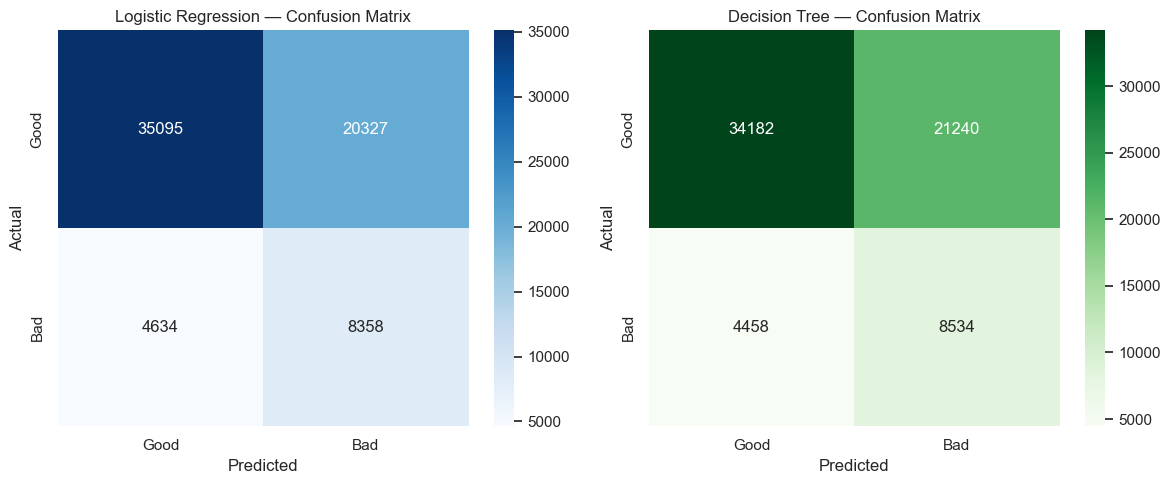

In [86]:
# ── Predictions ──────────────────────────────────────────────────────────────
y_pred_lr   = logreg.predict(X_final_test)
y_pred_tree = dtree.predict(X_final_test)
y_prob_lr   = logreg.predict_proba(X_final_test)[:, 1]
y_prob_tree = dtree.predict_proba(X_final_test)[:, 1]

# ── Confusion matrices ────────────────────────────────────────────────────────
cm_lr   = confusion_matrix(y_test, y_pred_lr)
cm_tree = confusion_matrix(y_test, y_pred_tree)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, cm, title, cmap in zip(
    axes,
    [cm_lr, cm_tree],
    ['Logistic Regression', 'Decision Tree'],
    ['Blues', 'Greens']
):
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, ax=ax,
                xticklabels=['Good', 'Bad'], yticklabels=['Good', 'Bad'])
    ax.set_title(f'{title} — Confusion Matrix')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
plt.tight_layout()
plt.show()

In [87]:
# ── Classification reports ────────────────────────────────────────────────────
print('=== Logistic Regression ===')
print(classification_report(y_test, y_pred_lr, target_names=['Good', 'Bad']))
print('=== Decision Tree ===')
print(classification_report(y_test, y_pred_tree, target_names=['Good', 'Bad']))

=== Logistic Regression ===
              precision    recall  f1-score   support

        Good       0.88      0.63      0.74     55422
         Bad       0.29      0.64      0.40     12992

    accuracy                           0.64     68414
   macro avg       0.59      0.64      0.57     68414
weighted avg       0.77      0.64      0.67     68414

=== Decision Tree ===
              precision    recall  f1-score   support

        Good       0.88      0.62      0.73     55422
         Bad       0.29      0.66      0.40     12992

    accuracy                           0.62     68414
   macro avg       0.59      0.64      0.56     68414
weighted avg       0.77      0.62      0.66     68414



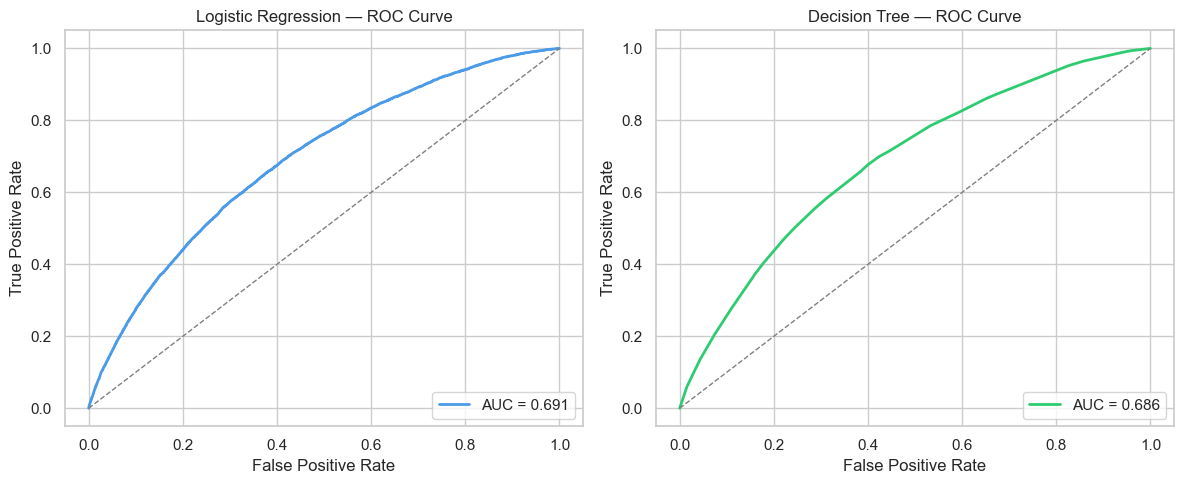

AUC — Logistic Regression: 0.6907
AUC — Decision Tree      : 0.6861


In [88]:
# ── ROC curves ───────────────────────────────────────────────────────────────
fpr_lr,   tpr_lr,   thr_lr   = roc_curve(y_test, y_prob_lr)
fpr_tree, tpr_tree, thr_tree = roc_curve(y_test, y_prob_tree)
auc_lr   = auc(fpr_lr,   tpr_lr)
auc_tree = auc(fpr_tree, tpr_tree)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, fpr, tpr, roc_auc, label, color in zip(
    axes,
    [fpr_lr,   fpr_tree],
    [tpr_lr,   tpr_tree],
    [auc_lr,   auc_tree],
    ['Logistic Regression', 'Decision Tree'],
    ['#4C9BE8', '#2ECC71']
):
    ax.plot(fpr, tpr, color=color, lw=2,
            label=f'AUC = {roc_auc:.3f}')
    ax.plot([0, 1], [0, 1], 'gray', linestyle='--', lw=1)
    ax.set_title(f'{label} — ROC Curve')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.legend(loc='lower right')
plt.tight_layout()
plt.show()
print(f'AUC — Logistic Regression: {auc_lr:.4f}')
print(f'AUC — Decision Tree      : {auc_tree:.4f}')

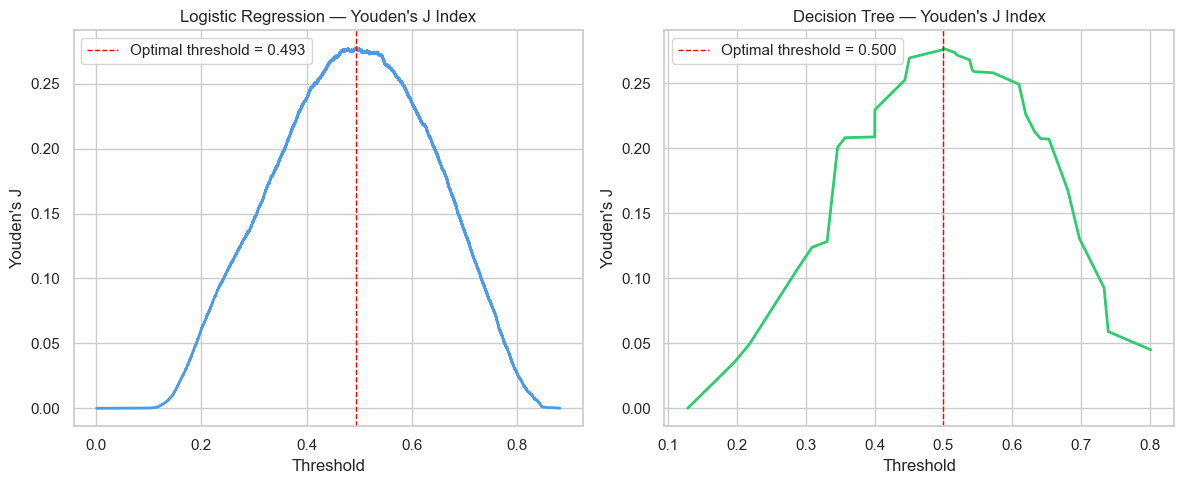

Optimal threshold — Logistic Regression: 0.4932
Optimal threshold — Decision Tree      : 0.4999


In [89]:
# ── Youden's J Index — find optimal classification threshold ─────────────────
j_lr   = tpr_lr   - fpr_lr
j_tree = tpr_tree - fpr_tree

best_thr_lr   = thr_lr[np.argmax(j_lr)]
best_thr_tree = thr_tree[np.argmax(j_tree)]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, thr, j, best_thr, label, color in zip(
    axes,
    [thr_lr,   thr_tree],
    [j_lr,     j_tree],
    [best_thr_lr, best_thr_tree],
    ['Logistic Regression', 'Decision Tree'],
    ['#4C9BE8', '#2ECC71']
):
    ax.plot(thr, j, color=color, lw=2)
    ax.axvline(best_thr, color='red', linestyle='--', lw=1,
               label=f'Optimal threshold = {best_thr:.3f}')
    ax.set_title(f"{label} — Youden's J Index")
    ax.set_xlabel('Threshold')
    ax.set_ylabel("Youden's J")
    ax.legend()
plt.tight_layout()
plt.show()
print(f'Optimal threshold — Logistic Regression: {best_thr_lr:.4f}')
print(f'Optimal threshold — Decision Tree      : {best_thr_tree:.4f}')

### Later addition Explainable Boosting Machine (EBM): 

In [99]:
# EBM takes RAW features (post-cleaning, pre-WOE, pre-scaling).
# Reasons:
#   - WOE collapses non-linear signals that EBM can discover on its own
#   - StandardScaler has zero effect on tree-based splits (rank-invariant)
#   - Shape functions in original units (dollars, months) are readable by humans
#
# Input: X_train_raw, X_test_raw from Section 5 (after outlier treatment)
# ─────────────────────────────────────────────────────────────────────────────

# ── Step 1: Prepare raw features ─────────────────────────────────────────────
# EBM handles numerics natively. For categoricals, convert to string so
# InterpretML treats them correctly (it handles object dtype columns as
# categorical automatically). We only keep useful_features (IV-filtered)
# so the feature space matches what we validated in Section 7.

ebm_train = X_train_raw[useful_features].copy()
ebm_test  = X_test_raw[useful_features].copy()

# Convert object columns to string (EBM categorical handling)
cat_cols = ebm_train.select_dtypes(include='object').columns.tolist()
for col in cat_cols:
    ebm_train[col] = ebm_train[col].astype(str)
    ebm_test[col]  = ebm_test[col].astype(str)

# Fill any residual NaNs (numeric → median, categorical → 'Unknown')
num_cols_ebm = ebm_train.select_dtypes(include='number').columns
for col in num_cols_ebm:
    med = ebm_train[col].median()
    ebm_train[col] = ebm_train[col].fillna(med)
    ebm_test[col]  = ebm_test[col].fillna(med)
for col in cat_cols:
    ebm_train[col] = ebm_train[col].fillna('Unknown')
    ebm_test[col]  = ebm_test[col].fillna('Unknown')

print(f'EBM input shape — Train: {ebm_train.shape}, Test: {ebm_test.shape}')
print(f'Categorical features passed to EBM: {cat_cols}')

EBM input shape — Train: (159632, 7), Test: (68414, 7)
Categorical features passed to EBM: ['grade', 'issue_d', 'purpose', 'term']


In [100]:
# ── Step 2: Fit EBM ──────────────────────────────────────────────────────────
# Key hyperparameters:
#   interactions=10    → allow up to 10 pairwise interaction terms (GA²M)
#   max_bins=256       → granularity of shape function (more = smoother curve)
#   min_samples_leaf=5 → prevents overfitting on small groups

ebm = ExplainableBoostingClassifier(
    interactions=10,
    max_bins=256,
    min_samples_leaf=5,
    random_state=RANDOM_STATE
)
ebm.fit(ebm_train, y_train_clean)

y_prob_ebm = ebm.predict_proba(ebm_test)[:, 1]
y_pred_ebm = (y_prob_ebm >= best_thr_lr).astype(int)  # reuse optimal threshold from LR

print('EBM training complete.')

EBM training complete.


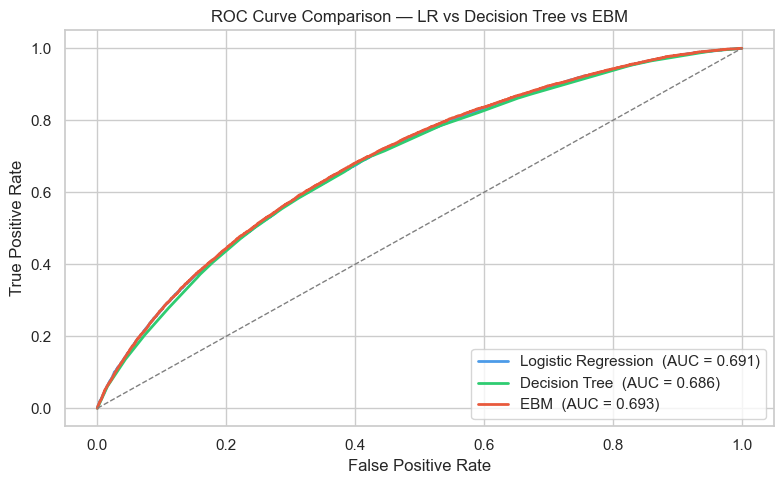


AUC — Logistic Regression : 0.6907
AUC — Decision Tree       : 0.6861
AUC — EBM                 : 0.6932

EBM vs LR gap: +0.0025
→ Negligible gap: WOE + LR captures the signal well. LR is justified.


In [101]:
# ── Step 3: AUC comparison across all three models ───────────────────────────
# Inference: if EBM AUC >> LR AUC (gap > 0.03), the linear log-odds
# assumption in LR is losing real signal → revisit WOE bin coarseness.
# If gap is small, WOE + LR is sufficient and simpler to deploy.

from sklearn.metrics import roc_curve, auc

fpr_ebm, tpr_ebm, _ = roc_curve(y_test, y_prob_ebm)
auc_ebm = auc(fpr_ebm, tpr_ebm)

fig, ax = plt.subplots(figsize=(8, 5))
for fpr, tpr, roc_auc, label, color in [
    (fpr_lr,   tpr_lr,   auc_lr,   'Logistic Regression', '#4C9BE8'),
    (fpr_tree, tpr_tree, auc_tree, 'Decision Tree',       '#2ECC71'),
    (fpr_ebm,  tpr_ebm,  auc_ebm,  'EBM',                 '#E8593C'),
]:
    ax.plot(fpr, tpr, color=color, lw=2, label=f'{label}  (AUC = {roc_auc:.3f})')

ax.plot([0, 1], [0, 1], 'gray', linestyle='--', lw=1)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve Comparison — LR vs Decision Tree vs EBM')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

gap = auc_ebm - auc_lr
print(f'\nAUC — Logistic Regression : {auc_lr:.4f}')
print(f'AUC — Decision Tree       : {auc_tree:.4f}')
print(f'AUC — EBM                 : {auc_ebm:.4f}')
print(f'\nEBM vs LR gap: {gap:+.4f}')
if gap > 0.03:
    print('→ Significant gap: LR is losing signal. Review WOE bin coarseness.')
elif gap > 0.01:
    print('→ Modest gap: WOE linearisation is mostly working. EBM adds marginal lift.')
else:
    print('→ Negligible gap: WOE + LR captures the signal well. LR is justified.')

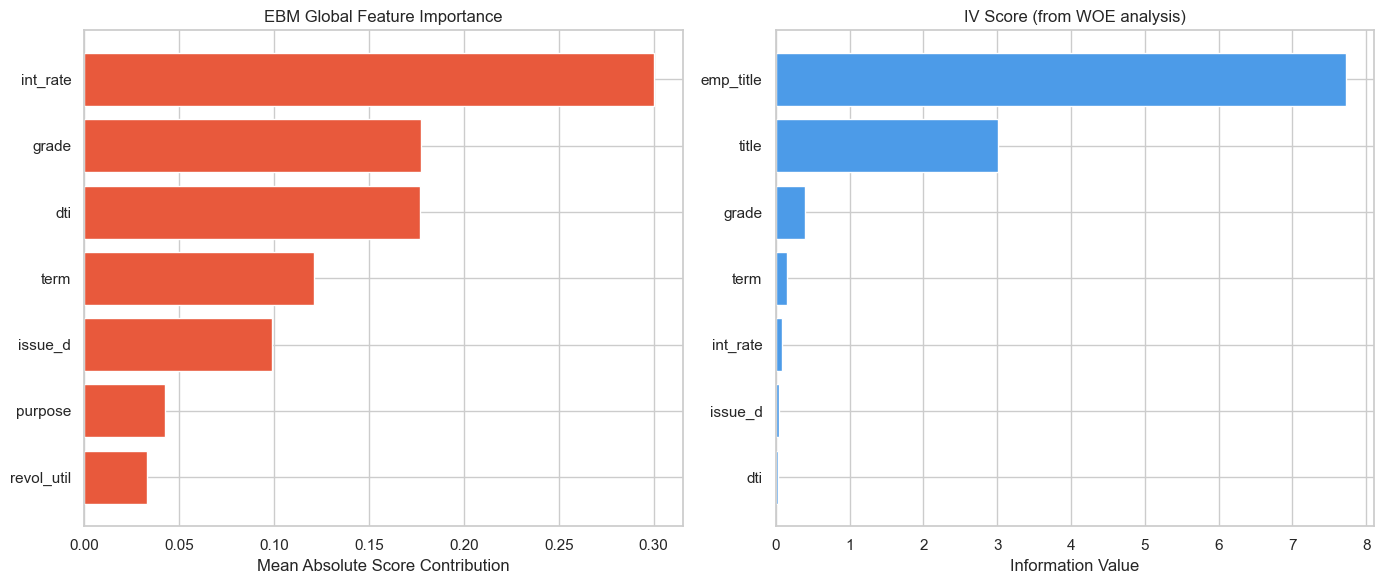


Ranking comparison (features where EBM and IV disagree most):
   feature  ebm_rank  iv_rank  rank_diff  ebm_importance  iv_score
  int_rate       1.0      3.0          2        0.300324  0.085250
       dti       3.0      5.0          2        0.176848  0.025529
      term       4.0      2.0          2        0.120853  0.155273
     grade       2.0      1.0          1        0.177545  0.394449
   issue_d       5.0      4.0          1        0.098722  0.044969
   purpose       6.0      6.0          0        0.042395  0.025014
revol_util       7.0      7.0          0        0.032982  0.021140


In [105]:
# ── Step 4: Global feature importance vs IV ranking ──────────────────────────
# Inference: EBM importance should broadly agree with IV ranking.
# Disagreements are the interesting cases:
#   - High EBM importance + Low IV → IV binning was too coarse, missed the signal
#   - Low EBM importance + High IV → variable may have been over-fitted in WOE bins,
#     or the signal is only useful in combination (check interactions below)

# Keep only main-effect importances (exclude interaction terms)
feature_names = ebm.feature_names_in_

main_effect_importances = ebm.term_importances()[:len(feature_names)]

ebm_importances = (
    pd.DataFrame({
        'feature': feature_names,
        'ebm_importance': main_effect_importances
    })
    .sort_values('ebm_importance', ascending=False)
    .reset_index(drop=True)
)

# Merge with IV to compare rankings side by side
iv_clean = IV.rename(columns={'VAR_NAME': 'feature', 'IV': 'iv_score'}).copy()
importance_comparison = ebm_importances.merge(iv_clean, on='feature', how='left')
importance_comparison['iv_rank']  = importance_comparison['iv_score'].rank(ascending=False)
importance_comparison['ebm_rank'] = importance_comparison['ebm_importance'].rank(ascending=False)
importance_comparison['rank_diff'] = (
    importance_comparison['iv_rank'] - importance_comparison['ebm_rank']
).abs().astype(int)

# Plot side-by-side
top_n = min(15, len(ebm_importances))
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# EBM importance
top_ebm = ebm_importances.head(top_n)
axes[0].barh(top_ebm['feature'][::-1], top_ebm['ebm_importance'][::-1], color='#E8593C')
axes[0].set_title('EBM Global Feature Importance')
axes[0].set_xlabel('Mean Absolute Score Contribution')

# IV score
top_iv = IV.sort_values('IV', ascending=False).head(top_n)
axes[1].barh(top_iv['VAR_NAME'][::-1], top_iv['IV'][::-1], color='#4C9BE8')
axes[1].set_title('IV Score (from WOE analysis)')
axes[1].set_xlabel('Information Value')

plt.tight_layout()
plt.show()

print('\nRanking comparison (features where EBM and IV disagree most):')
print(importance_comparison.sort_values('rank_diff', ascending=False)
      [['feature', 'ebm_rank', 'iv_rank', 'rank_diff', 'ebm_importance', 'iv_score']]
      .head(8).to_string(index=False))

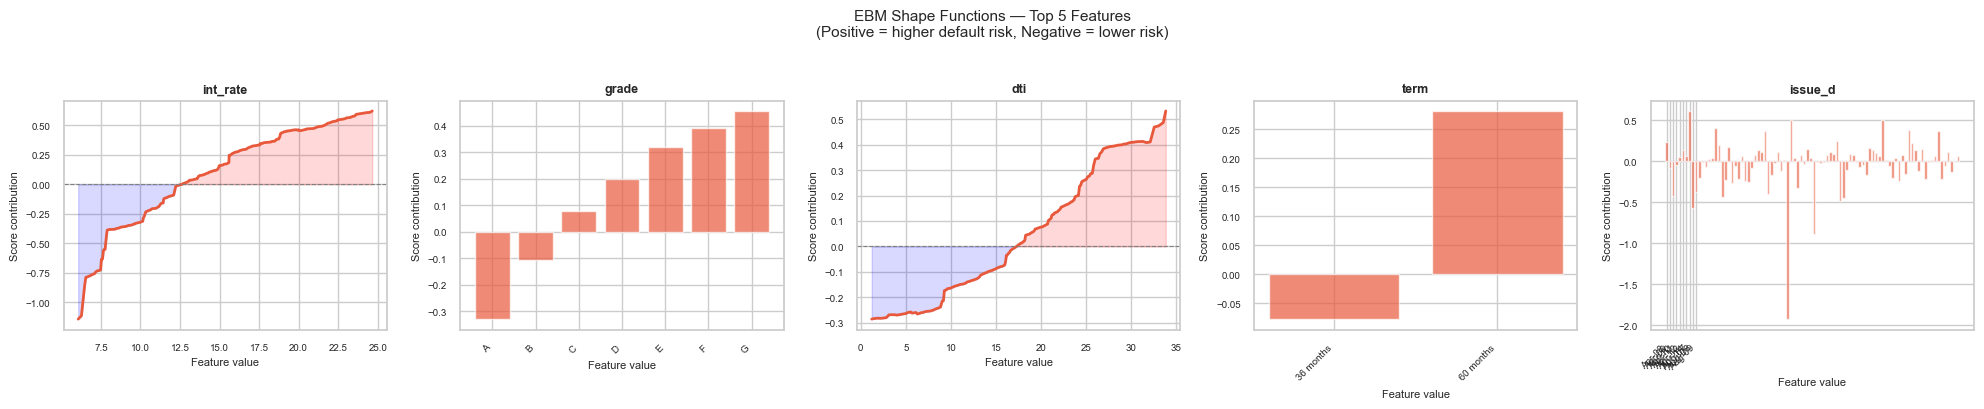

In [107]:
# ── Step 5: Shape functions for top-5 features ───────────────────────────────
# Inference: Compare each shape curve against the WOE trend from Section 6.
# They should broadly agree (both should be monotonic for most variables).
# A U-shape or S-shape in EBM that WOE doesn't capture = WOE bins too coarse.
# A flat EBM curve for a high-IV variable = that variable's signal is mostly
# captured by an interaction term, not the main effect (check interactions below).

top5_features = ebm_importances.head(5)['feature'].tolist()
ebm_global    = ebm.explain_global()

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for ax, feat in zip(axes, top5_features):
    feat_idx  = list(ebm.feature_names_in_).index(feat)
    feat_data = ebm_global.data(feat_idx)

    x_vals = feat_data.get('names', feat_data.get('names', []))
    y_vals = feat_data.get('scores', [])

    if len(x_vals) == 0 or len(y_vals) == 0:
        ax.set_title(feat)
        ax.text(0.5, 0.5, 'No data', ha='center', va='center',
                transform=ax.transAxes)
        continue

    # For continuous features: line plot. For categorical: bar.
    if isinstance(x_vals[0], str):
        ax.bar(range(len(y_vals)), y_vals, color='#E8593C', alpha=0.7)
        ax.set_xticks(range(len(x_vals[:10])))
        ax.set_xticklabels(x_vals[:10], rotation=45, ha='right', fontsize=7)
    else:
        # x_vals are bin edges — use midpoints for plotting
        if len(x_vals) == len(y_vals) + 1:
            x_mid = [(x_vals[i] + x_vals[i+1]) / 2 for i in range(len(y_vals))]
        else:
            x_mid = x_vals[:len(y_vals)]
        ax.plot(x_mid, y_vals, color='#E8593C', lw=2)
        ax.axhline(0, color='gray', linestyle='--', lw=0.8)
        ax.fill_between(x_mid, y_vals, 0,
                        where=[v > 0 for v in y_vals],
                        alpha=0.15, color='red', label='Higher risk')
        ax.fill_between(x_mid, y_vals, 0,
                        where=[v <= 0 for v in y_vals],
                        alpha=0.15, color='blue', label='Lower risk')

    ax.set_title(feat, fontsize=9, fontweight='bold')
    ax.set_xlabel('Feature value', fontsize=8)
    ax.set_ylabel('Score contribution', fontsize=8)
    ax.tick_params(labelsize=7)

fig.suptitle('EBM Shape Functions — Top 5 Features\n'
             '(Positive = higher default risk, Negative = lower risk)',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

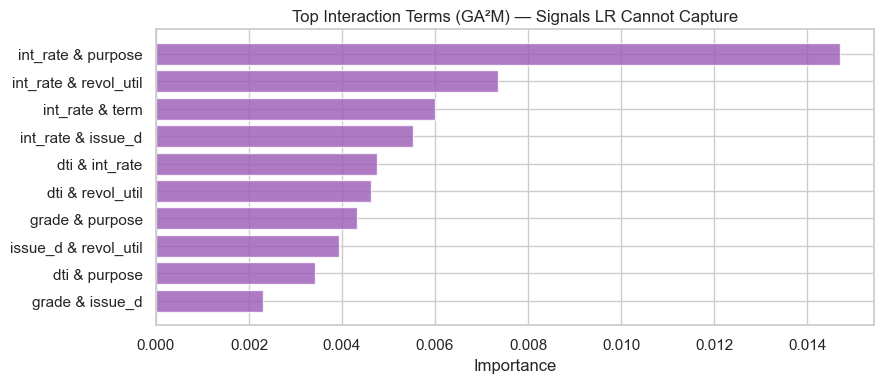


Top interaction terms:
          interaction  importance
   int_rate & purpose    0.014704
int_rate & revol_util    0.007347
      int_rate & term    0.006004
   int_rate & issue_d    0.005519
       dti & int_rate    0.004748
     dti & revol_util    0.004633
      grade & purpose    0.004329
 issue_d & revol_util    0.003932
        dti & purpose    0.003414
      grade & issue_d    0.002305


In [108]:
# ── Step 6: Interaction terms ─────────────────────────────────────────────────
# Inference: Interaction terms show where two features JOINTLY influence
# risk beyond their individual effects. A strong interaction that IV missed
# is genuinely new information — it cannot be captured by LR at all.
# Example: low income AND high DTI is far riskier than either alone.

interaction_terms = [
    name for name in ebm.term_names_
    if ' x ' in name or ' & ' in name
]
interaction_importance = []
for name in interaction_terms:
    idx = list(ebm.term_names_).index(name)
    interaction_importance.append({
        'interaction': name,
        'importance' : ebm.term_importances()[idx]
    })

int_df = (pd.DataFrame(interaction_importance)
          .sort_values('importance', ascending=False)
          .head(10)
          .reset_index(drop=True))

if not int_df.empty:
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.barh(int_df['interaction'][::-1], int_df['importance'][::-1],
            color='#9B59B6', alpha=0.8)
    ax.set_title('Top Interaction Terms (GA²M) — Signals LR Cannot Capture')
    ax.set_xlabel('Importance')
    plt.tight_layout()
    plt.show()
    print('\nTop interaction terms:')
    print(int_df.to_string(index=False))
else:
    print('No meaningful interaction terms found — LR linearity assumption holds.')

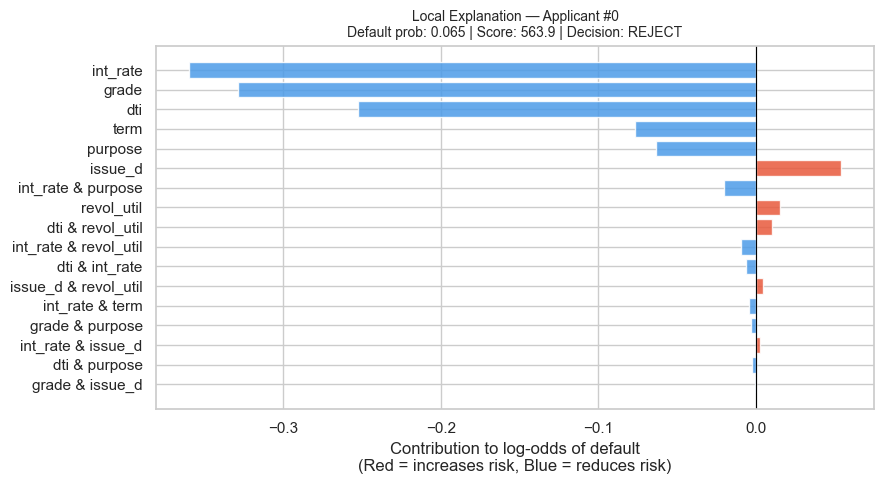


Applicant #0 — Adverse Action Detail
  Actual outcome : Good
  Predicted prob : 0.0654
  Credit score   : 563.9
  Decision       : REJECT

Top reasons for decision (sorted by impact):
           feature       value  contribution
          int_rate         8.9     -0.360148
             grade           A     -0.328776
               dti        7.78     -0.252390
              term   36 months     -0.076908
           purpose credit_card     -0.062957
           issue_d      Apr-12      0.054473
int_rate & purpose interaction     -0.020271
        revol_util        82.5      0.015645


In [ ]:
# ── Step 7: Local explanation — per-applicant adverse action notice ───────────
# produce a ranked list of reasons for EACH individual decision.
# Inference: For any rejected applicant, you can tell them exactly which
# features hurt their score and by how much — regulatory requirement.

sample_idx    = 0  # change to any test-set index
sample_input  = ebm_test.iloc[[sample_idx]]
actual_label  = y_test.iloc[sample_idx]
pred_prob     = ebm.predict_proba(sample_input)[0, 1]
pred_score    = probability_to_score(pred_prob)
decision      = 'APPROVE' if pred_score >= SCORE_CUTOFF else 'REJECT'

# Local explanation
ebm_local     = ebm.explain_local(sample_input, y_test.iloc[[sample_idx]])
local_data    = ebm_local.data(0)

contrib_df = pd.DataFrame({
    'feature'     : local_data['names'],
    'value'       : [
        sample_input.iloc[0][f] if f in sample_input.columns else 'interaction'
        for f in local_data['names']
    ],
    'contribution': local_data['scores']
}).sort_values('contribution', key=abs, ascending=False)

# Plot
fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#E8593C' if v > 0 else '#4C9BE8' for v in contrib_df['contribution']]
ax.barh(contrib_df['feature'][::-1], contrib_df['contribution'][::-1],
        color=colors[::-1], alpha=0.85)
ax.axvline(0, color='black', lw=0.8)
ax.set_title(
    f'Local Explanation — Applicant #{sample_idx}\n'
    f'Default prob: {pred_prob:.3f} | Score: {pred_score:.1f} | Decision: {decision}',
    fontsize=10
)
ax.set_xlabel('Contribution to log-odds of default\n'
               '(Red = increases risk, Blue = reduces risk)')
plt.tight_layout()
plt.show()

print(f'\nApplicant #{sample_idx} — Adverse Action Detail')
print(f'  Actual outcome : {"Bad" if actual_label == 1 else "Good"}')
print(f'  Predicted prob : {pred_prob:.4f}')
print(f'  Credit score   : {pred_score:.1f}')
print(f'  Decision       : {decision}')
print(f'\nTop reasons for decision (sorted by impact):')
print(contrib_df[['feature', 'value', 'contribution']].head(8).to_string(index=False))

In [ ]:
# ── Step 8: New applicant ---

new_applicant = pd.DataFrame({
    'int_rate': [18.5],
    'grade': ['E'],
    'dti': [28],
    'term': ['60 months'],
    'issue_d': ['2015-06'],
    'purpose': ['debt_consolidation'],
    'revol_util': [72]
})

pred_prob = ebm.predict_proba(new_applicant)[:, 1][0]

print(f'Default Probability: {pred_prob:.2%}')

if pred_prob < 0.15:
    decision = "ACCEPT"

elif pred_prob < 0.30:
    decision = "MANUAL REVIEW"

else:
    decision = "REJECT"

print("Decision:", decision)

local_exp = ebm.explain_local(new_applicant)

show(local_exp)

Default Probability: 37.71%
Decision: REJECT


<!-- http://127.0.0.1:7001/2412613077648/ -->

---
## Section 13 — Score Scaling: Building the Actual Scorecard

In this section our purpose is to convert a model probability into a human-readable credit scorecard.

### The scaling formula

Scorecard points for each variable bin are computed as:

$$\text{Score}_i = \left(\beta_i \times \text{WOE}_i + \frac{\alpha}{N}\right) \times \text{Factor} + \frac{\text{Offset}}{N}$$

Where:
- $\beta_i$ = logistic regression coefficient for variable $i$
- $\alpha$ = intercept
- $N$ = number of variables in the model
- $\text{Factor} = \frac{\text{PDO}}{\ln(2)}$ — PDO (Points to Double the Odds) is typically 20
- $\text{Offset} = \text{BaseScore} - \text{Factor} \times \ln(\text{BaseOdds})$

### Calibration constants (from the PDF)
- **Base score = 600** → a borrower with a 50:1 Good/Bad ratio gets a score of 600.
- **PDO = 20** → every 20-point increase in score corresponds to a doubling of the Good/Bad odds.

These constants come from business requirements, not the data. They can be adjusted to 
shift the score range (e.g. 300–850 like FICO) or to tune approval thresholds.

### From probability to score

Given the model's predicted probability of default $p$, the score is:

$$\text{Score} = \text{Factor} \times \ln\left(\frac{1-p}{p}\right) + \text{Offset}$$

Higher score = lower probability of default = lower risk.

In [90]:
# ── Scorecard calibration constants ──────────────────────────────────────────
BASE_SCORE = 600   # score at BASE_ODDS good-to-bad ratio
BASE_ODDS  = 50    # 50:1 good-to-bad at BASE_SCORE
PDO        = 20    # points to double the odds

FACTOR = PDO / np.log(2)
OFFSET = BASE_SCORE - FACTOR * np.log(BASE_ODDS)

print(f'Factor : {FACTOR:.4f}')
print(f'Offset : {OFFSET:.4f}')
print(f'\nInterpretation:')
print(f'  Score {BASE_SCORE} → odds {BASE_ODDS}:1 (good:bad)')
print(f'  Score {BASE_SCORE + PDO} → odds {BASE_ODDS * 2}:1 (doubling)')
print(f'  Score {BASE_SCORE - PDO} → odds {BASE_ODDS // 2}:1 (halving)')

Factor : 28.8539
Offset : 487.1229

Interpretation:
  Score 600 → odds 50:1 (good:bad)
  Score 620 → odds 100:1 (doubling)
  Score 580 → odds 25:1 (halving)


In [91]:
def probability_to_score(prob, factor=FACTOR, offset=OFFSET):
    """
    Convert a default probability to a credit score.

    Higher score = lower default probability = better borrower.

    Parameters
    ----------
    prob   : float or array-like — predicted probability of default (class 1)
    factor : scaling factor (PDO / ln(2))
    offset : base offset

    Returns
    -------
    Credit score (float or array)
    """
    prob = np.clip(prob, 1e-7, 1 - 1e-7)   # prevent log(0)
    odds = (1 - prob) / prob                 # good-to-bad odds
    return factor * np.log(odds) + offset


# ── Generate scores for the test set ─────────────────────────────────────────
test_scores = probability_to_score(y_prob_lr)

print(f'Score statistics (test set):')
print(f'  Min  : {test_scores.min():.1f}')
print(f'  Max  : {test_scores.max():.1f}')
print(f'  Mean : {test_scores.mean():.1f}')
print(f'  Std  : {test_scores.std():.1f}')

Score statistics (test set):
  Min  : 429.3
  Max  : 682.0
  Mean : 491.7
  Std  : 21.6


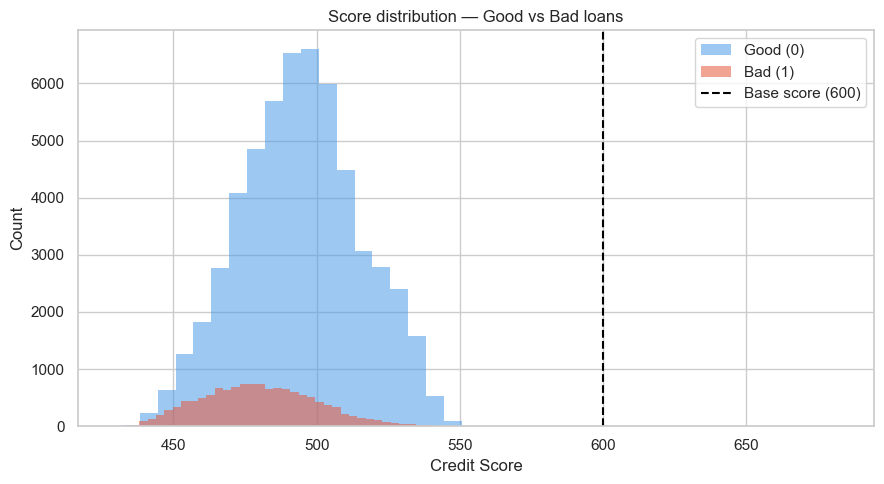

In [92]:
# ── Score distribution by actual outcome ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
for label, color in [(0, '#4C9BE8'), (1, '#E8593C')]:
    mask = y_test == label
    ax.hist(test_scores[mask], bins=40, alpha=0.55, color=color,
            label='Good (0)' if label == 0 else 'Bad (1)',
            edgecolor='none')
ax.axvline(BASE_SCORE, color='black', linestyle='--', lw=1.5,
           label=f'Base score ({BASE_SCORE})')
ax.set_xlabel('Credit Score')
ax.set_ylabel('Count')
ax.set_title('Score distribution — Good vs Bad loans')
ax.legend()
plt.tight_layout()
plt.show()

In [93]:
# ── Per-variable scorecard table ─────────────────────────────────────────────
# Compute the points each variable bin contributes to the total score.
# This is the traditional scorecard output: a lookup table per variable.

N_vars = len(significant_vars)
coefs  = dict(zip(significant_vars, logreg.coef_[0]))
alpha  = logreg.intercept_[0]

scorecard_rows = []
for var in significant_vars:
    orig_var = var.replace('new_', '', 1)   # strip transformation prefix
    var_iv   = final_iv[final_iv['VAR_NAME'] == orig_var]
    beta     = coefs[var]

    for _, row in var_iv.iterrows():
        woe   = row['WOE']
        score = (beta * woe + alpha / N_vars) * FACTOR + OFFSET / N_vars
        scorecard_rows.append({
            'Variable'        : orig_var,
            'Min Value'       : row['MIN_VALUE'],
            'Max Value'       : row['MAX_VALUE'],
            'WOE'             : round(woe, 4),
            'Scorecard Points': round(score, 1)
        })

scorecard_df = pd.DataFrame(scorecard_rows)
print('Sample scorecard table:')
scorecard_df.head(20)

Sample scorecard table:


,Variable,Min Value,Max Value,WOE,Scorecard Points
0,dti,1.22,4.82,-0.4583,66.3
1,dti,4.82,7.23,-0.4231,66.5
2,dti,7.23,9.07,-0.3612,66.8
3,dti,9.07,10.67,-0.2564,67.4
4,dti,10.67,12.1,-0.2191,67.7
5,dti,12.1,13.45,-0.2034,67.8
6,dti,13.45,14.75,-0.1301,68.2
7,dti,14.75,16.08,-0.1216,68.2
8,dti,16.08,17.41,-0.0214,68.8
9,dti,17.41,18.81,0.0363,69.1


In [94]:
# ── Decision making: approve if score >= cutoff ───────────────────────────────
SCORE_CUTOFF = BASE_SCORE   # can be tuned based on business risk appetite

decisions = np.where(test_scores >= SCORE_CUTOFF, 'APPROVE', 'REJECT')

approval_df = pd.DataFrame({
    'Predicted Probability': y_prob_lr.round(4),
    'Credit Score'         : test_scores.round(1),
    'Decision'             : decisions,
    'Actual Outcome'       : y_test.map({0: 'Good', 1: 'Bad'})
})

print('Decision summary:')
print(approval_df['Decision'].value_counts())
print()
print('Approval rate by actual outcome:')
print(approval_df.groupby('Actual Outcome')['Decision']
      .value_counts(normalize=True).mul(100).round(1))
approval_df.head(10)

Decision summary:
Decision
REJECT     68405
APPROVE        9
Name: count, dtype: int64

Approval rate by actual outcome:
Actual Outcome  Decision
Bad             REJECT      100.0
Good            REJECT      100.0
                APPROVE       0.0
Name: proportion, dtype: float64


,Predicted Probability,Credit Score,Decision,Actual Outcome
0,0.2202,523.6,REJECT,Good
1,0.3251,508.2,REJECT,Bad
2,0.5576,480.4,REJECT,Good
3,0.4250,495.8,REJECT,Good
4,0.6487,469.4,REJECT,Bad
5,0.2274,522.4,REJECT,Good
6,0.5387,482.7,REJECT,Good
7,0.6078,474.5,REJECT,Good
8,0.2667,516.3,REJECT,Good
9,0.4530,492.6,REJECT,Bad


---
## Section 14 — Model Persistence

To score a new loan applicant in production, you need:

| Artefact | What it does |
|----------|--------------|
| `woe_table.csv` | Maps every feature bin to a WOE value for the transformation step |
| `iv_summary.csv` | Stores IV scores to know which features to include |
| `scaler.pkl` | The fitted `StandardScaler` — must use the same mean/std as training |
| `logistic_model.pkl` | The fitted `LogisticRegression` model |
| `scorecard_table.csv` | Human-readable scorecard lookup table for deployment |
| `model_metadata.json` | Calibration constants and feature list |

Without these files saved, you would have to retrain the model from scratch to score 
a single new application — which is impractical and risks subtle differences each time 
(e.g. if training data is updated).

In [95]:
# ── Save all artefacts ────────────────────────────────────────────────────────
joblib.dump(scaler,  ARTEFACTS / 'scaler.pkl')
joblib.dump(logreg,  ARTEFACTS / 'logistic_model.pkl')
joblib.dump(dtree,   ARTEFACTS / 'decision_tree.pkl')

final_iv.to_csv(    ARTEFACTS / 'woe_table.csv',      index=False)
IV.to_csv(           ARTEFACTS / 'iv_summary.csv',     index=False)
scorecard_df.to_csv(ARTEFACTS / 'scorecard_table.csv', index=False)

metadata = {
    'model_features'  : significant_vars,
    'useful_features' : useful_features,
    'iv_lower_cutoff' : IV_LOWER,
    'iv_upper_cutoff' : IV_UPPER,
    'base_score'      : BASE_SCORE,
    'base_odds'       : BASE_ODDS,
    'pdo'             : PDO,
    'factor'          : round(FACTOR, 6),
    'offset'          : round(OFFSET, 6),
    'score_cutoff'    : SCORE_CUTOFF,
    'random_state'    : RANDOM_STATE,
}
with open(ARTEFACTS / 'model_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print('Saved artefacts:')
for p in sorted(ARTEFACTS.iterdir()):
    print(f'  {p.name}  ({p.stat().st_size / 1024:.1f} KB)')

Saved artefacts:
  decision_tree.pkl  (6.5 KB)
  iv_summary.csv  (0.7 KB)
  logistic_model.pkl  (1.3 KB)
  model_metadata.json  (0.5 KB)
  scaler.pkl  (1.0 KB)
  scorecard_table.csv  (5.6 KB)
  woe_table.csv  (15871.6 KB)


---
## Section 15 — Scoring a New Applicant (Inference Pipeline)

This section demonstrates how to load saved artefacts and score a **brand-new** 
loan application. This is the code that would live in a production API endpoint.

The pipeline is:
```
New applicant data
  → apply_woe_transformation (using saved woe_table)
  → scaler.transform         (using saved scaler)
  → logreg.predict_proba     (using saved model)
  → probability_to_score     (using saved calibration constants)
  → compare to SCORE_CUTOFF → APPROVE / REJECT
```

In [96]:
# ── Load artefacts ───────────────────────────────────────────────────────────
loaded_scaler = joblib.load(ARTEFACTS / 'scaler.pkl')
loaded_model  = joblib.load(ARTEFACTS / 'logistic_model.pkl')
loaded_woe    = pd.read_csv(ARTEFACTS / 'woe_table.csv')
with open(ARTEFACTS / 'model_metadata.json') as f:
    meta = json.load(f)

print('Artefacts loaded. Model features:', meta['model_features'])

Artefacts loaded. Model features: ['new_dti', 'new_grade', 'new_int_rate', 'new_issue_d', 'new_purpose', 'new_revol_util', 'new_term']


In [97]:
def score_applicant(applicant_dict: dict) -> dict:
    """
    Score a single new loan applicant end-to-end.

    Parameters
    ----------
    applicant_dict : dict with raw feature values (same columns as training data)

    Returns
    -------
    dict with 'probability', 'score', and 'decision'
    """
    applicant_df = pd.DataFrame([applicant_dict])

    # Step 1: WOE transformation
    applicant_woe = apply_woe_transformation(
        applicant_df[meta['useful_features']],
        loaded_woe,
        target_col=None
    )

    # Step 2: Scale (using training statistics only)
    model_features = meta['model_features']
    new_feat_names = ['new_' + f.replace('new_', '', 1) for f in model_features]
    # model_features already has 'new_' prefix; use directly
    X_applicant = applicant_woe[model_features]
    X_scaled    = loaded_scaler.transform(X_applicant)

    # Step 3: Predict probability of default
    prob_default = loaded_model.predict_proba(X_scaled)[0, 1]

    # Step 4: Convert to credit score
    score = probability_to_score(
        prob_default,
        factor=meta['factor'],
        offset=meta['offset']
    )

    return {
        'default_probability': round(float(prob_default), 4),
        'credit_score'       : round(float(score), 1),
        'decision'           : 'APPROVE' if score >= meta['score_cutoff'] else 'REJECT'
    }


# ── Example: score a test applicant ──────────────────────────────────────────
# Use the first row of the test set as a demonstration
sample_applicant = X_test_raw.iloc[0][meta['useful_features']].to_dict()
result = score_applicant(sample_applicant)

print('Sample applicant result:')
for k, v in result.items():
    print(f'  {k}: {v}')
print(f"\nActual outcome: {'Good' if y_test.iloc[0] == 0 else 'Bad'}")

Sample applicant result:
  default_probability: 0.2202
  credit_score: 523.6
  decision: REJECT

Actual outcome: Good


In [112]:
#--- New applicant ---

def calculate_credit_score(applicant, scorecard_df):

    total_score = 0

    for var in applicant.index:

        value = applicant[var]

        matching_rows = scorecard_df[
            (scorecard_df['Variable'] == var)
        ]

        for _, row in matching_rows.iterrows():

            min_val = row['Min Value']
            max_val = row['Max Value']

            # Numeric variables
            if pd.api.types.is_numeric_dtype(type(value)):

                if min_val <= value <= max_val:
                    total_score += row['Scorecard Points']
                    break

            # Categorical variables
            else:

                if str(value) == str(min_val):
                    total_score += row['Scorecard Points']
                    break

    return round(total_score, 1)

In [115]:
applicant = pd.Series({
    'dti': 27,
    'grade': 'B',
    'term': '60 months',
    'int_rate': 8,
    'purpose': 'debt_consolidation',
    'revol_util': 65
})

score = calculate_credit_score(applicant, scorecard_df)

print("Credit Score:", score)

if score >= 720:
    decision = "ACCEPT"

elif score >= 650:
    decision = "MANUAL REVIEW"

else:
    decision = "REJECT"

print("Decision:", decision)

Credit Score: 334.4
Decision: REJECT


---
## Summary of Key Takeaways

### What a real production scorecard would add:

- **Cross-validation** (e.g. 5-fold stratified) to get more reliable AUC estimates.
- **Population Stability Index (PSI)** to monitor if the input data distribution 
  drifts over time after deployment.
- **Gini coefficient** (= 2×AUC − 1) — the industry-standard discrimination metric 
  for credit models.
- **Characteristic Analysis** — plot of Bad Rate vs Score band to validate that the 
  score ranks risk monotonically.
- **Champion/Challenger framework** — run two model versions in parallel on live 
  traffic and compare performance before a full rollout.